# 04 – Community Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Methodology follows **Kaluza et al. (2010)**, *J. R. Soc. Interface*, Figure 3.

The paper identifies geographically coherent trading communities using modularity-based detection.  
Container ships: c=12, Q=0.605; Bulk dry: c=7, Q=0.592; Oil tankers: c=6, Q=0.716.

### Analyses performed
1. Louvain community detection (weighted undirected graph)
2. Modularity Q
3. Community size distribution
4. Community internal density
5. Community traffic (strength per community)
6. Top ports per community
7. 2015 vs 2025 comparison


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

from networkx.algorithms.community import greedy_modularity_communities, modularity

try:
    from networkx.algorithms.community import louvain_communities
    HAS_LOUVAIN = True
    print('Louvain available (NetworkX >= 2.7)')
except ImportError:
    HAS_LOUVAIN = False
    print('Louvain not available, using greedy modularity')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

print('NetworkX version:', nx.__version__)


Louvain available (NetworkX >= 2.7)
NetworkX version: 3.4.2


In [2]:
df_2015 = pd.read_csv('../EdgeList/shipping_network_2015.csv')
df_2025 = pd.read_csv('../EdgeList/shipping_network_2025.csv')


def build_weighted_undirected(df):
    Gu = nx.Graph()
    for _, row in df.iterrows():
        u, v, w = row['source'], row['target'], row['weight']
        if Gu.has_edge(u, v):
            Gu[u][v]['weight'] += w
        else:
            Gu.add_edge(u, v, weight=w)
    return Gu


def build_directed_weighted(df):
    return nx.from_pandas_edgelist(
        df, 'source', 'target', edge_attr='weight',
        create_using=nx.DiGraph())


Gu_2015 = build_weighted_undirected(df_2015)
Gd_2015 = build_directed_weighted(df_2015)
Gu_2025 = build_weighted_undirected(df_2025)
Gd_2025 = build_directed_weighted(df_2025)

print(f'2015: {Gu_2015.number_of_nodes():,} nodes, {Gu_2015.number_of_edges():,} edges')
print(f'2025: {Gu_2025.number_of_nodes():,} nodes, {Gu_2025.number_of_edges():,} edges')


2015: 7,097 nodes, 145,745 edges
2025: 7,717 nodes, 139,499 edges


## 1. Community Detection

We use **Louvain** (preferred, NetworkX >= 2.7) or **greedy modularity** as fallback.  
Both optimise the modularity Q = fraction of intra-community edges minus expectation under null model.


In [3]:
def detect_communities(Gu, seed=42):
    """Detect communities. Returns list of frozensets."""
    if HAS_LOUVAIN:
        try:
            comms = louvain_communities(Gu, weight='weight', seed=seed)
            method = 'Louvain'
        except Exception as e:
            print(f'Louvain failed ({e}), falling back to greedy')
            comms = list(greedy_modularity_communities(Gu, weight='weight'))
            method = 'Greedy modularity'
    else:
        comms = list(greedy_modularity_communities(Gu, weight='weight'))
        method = 'Greedy modularity'

    Q = modularity(Gu, comms, weight='weight')

    print(f'  Method: {method}')
    print(f'  Communities: {len(comms)}')
    print(f'  Modularity Q: {Q:.4f}')

    return comms, Q, method


print('=== 2015 ===')
comms_2015, Q_2015, method_2015 = detect_communities(Gu_2015)

print('\n=== 2025 ===')
comms_2025, Q_2025, method_2025 = detect_communities(Gu_2025)


=== 2015 ===
  Method: Louvain
  Communities: 28
  Modularity Q: 0.6987

=== 2025 ===
  Method: Louvain
  Communities: 34
  Modularity Q: 0.7196


## 2. Community Metrics


In [4]:
def community_metrics(Gu, comms, label):
    node_to_comm = {}
    for i, c in enumerate(comms):
        for n in c:
            node_to_comm[n] = i

    sizes = np.array([len(c) for c in comms])

    intra, inter = 0, 0
    intra_w, inter_w = 0.0, 0.0
    for u, v, d in Gu.edges(data=True):
        w = d.get('weight', 1)
        if node_to_comm.get(u) == node_to_comm.get(v):
            intra += 1
            intra_w += w
        else:
            inter += 1
            inter_w += w

    total_w = intra_w + inter_w

    # Internal densities
    densities = []
    for c in comms:
        sub = Gu.subgraph(c)
        n = sub.number_of_nodes()
        m = sub.number_of_edges()
        if n > 1:
            densities.append(2 * m / (n * (n - 1)))

    # Community strengths
    comm_strengths = []
    for c in comms:
        sub = Gu.subgraph(c)
        comm_strengths.append(sum(dict(sub.degree(weight='weight')).values()))

    print(f'\n=== Community Metrics: {label} ===')
    print(f'  Number of communities    : {len(comms)}')
    print(f'  Largest community (nodes): {sizes.max()}')
    print(f'  Smallest community       : {sizes.min()}')
    print(f'  Mean community size      : {sizes.mean():.1f}')
    print(f'  Intra-community edges    : {intra:,} ({intra/(intra+inter)*100:.1f}%)')
    print(f'  Inter-community edges    : {inter:,} ({inter/(intra+inter)*100:.1f}%)')
    print(f'  Intra-community traffic  : {intra_w/total_w*100:.1f}% of all voyages')
    print(f'  Mean internal density    : {np.mean(densities):.4f}')

    return {
        'sizes': sizes,
        'densities': densities,
        'comm_strengths': np.array(comm_strengths),
        'intra_edges': intra, 'inter_edges': inter,
        'intra_ratio': intra / (intra + inter),
        'intra_traffic_ratio': intra_w / total_w,
        'node_to_comm': node_to_comm,
    }


cm_2015 = community_metrics(Gu_2015, comms_2015, '2015')
cm_2025 = community_metrics(Gu_2025, comms_2025, '2025')



=== Community Metrics: 2015 ===
  Number of communities    : 28
  Largest community (nodes): 1990
  Smallest community       : 2
  Mean community size      : 253.5
  Intra-community edges    : 102,314 (70.2%)
  Inter-community edges    : 43,431 (29.8%)
  Intra-community traffic  : 84.2% of all voyages
  Mean internal density    : 0.4647

=== Community Metrics: 2025 ===
  Number of communities    : 34
  Largest community (nodes): 1735
  Smallest community       : 2
  Mean community size      : 227.0
  Intra-community edges    : 94,301 (67.6%)
  Inter-community edges    : 45,198 (32.4%)
  Intra-community traffic  : 83.4% of all voyages
  Mean internal density    : 0.3605


## 3. Community Size Distribution


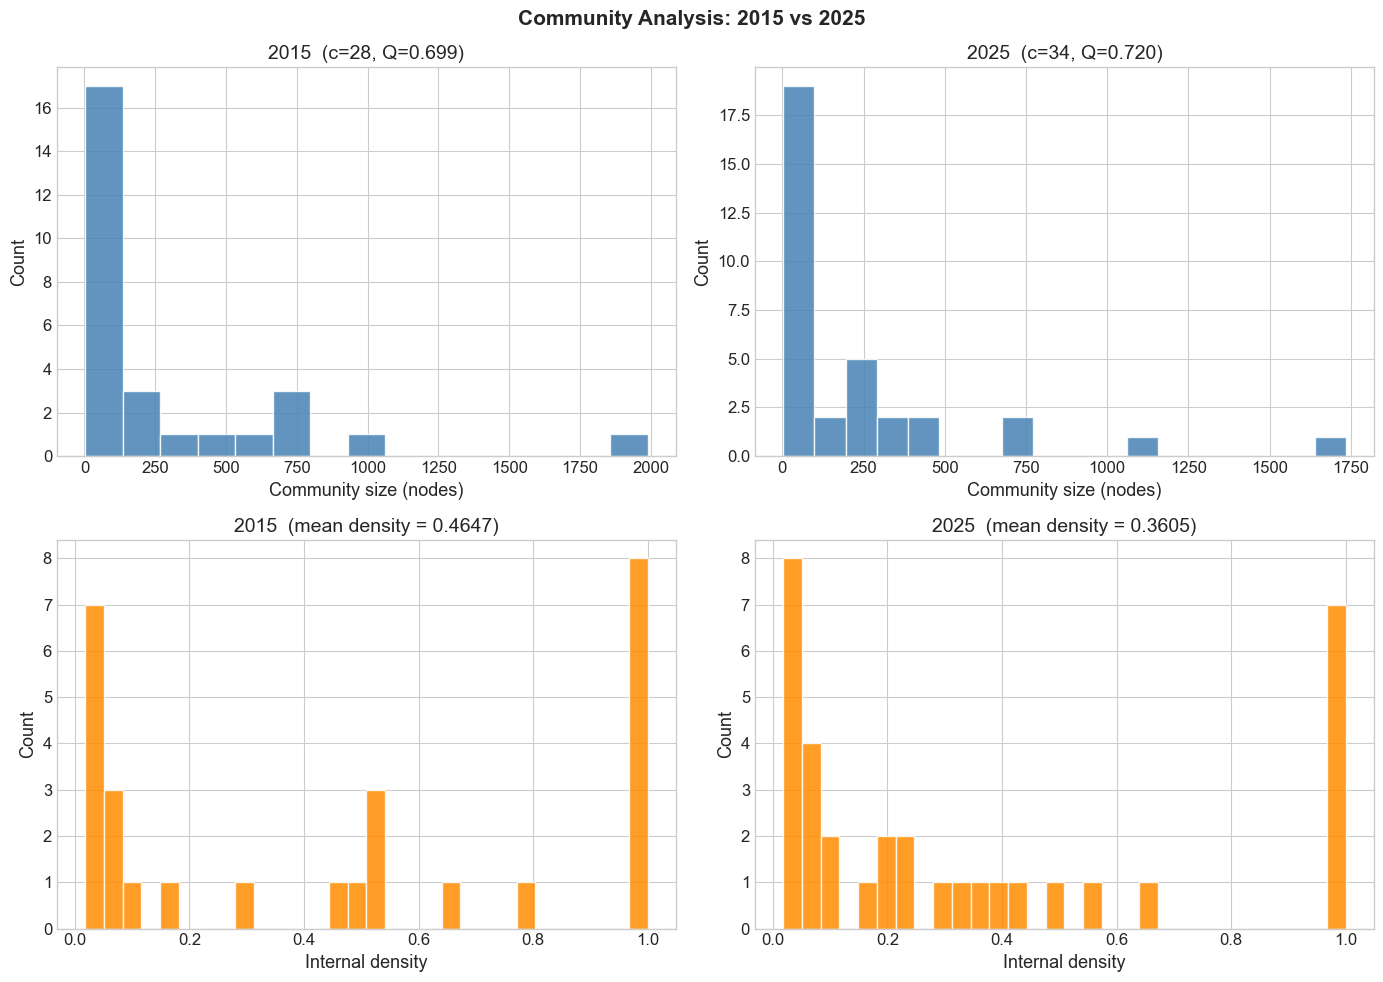

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Community Analysis: 2015 vs 2025', fontsize=15, fontweight='bold')

for col, (year, cm, Q) in enumerate([
    ('2015', cm_2015, Q_2015),
    ('2025', cm_2025, Q_2025)
]):
    sizes = cm['sizes']
    densities = np.array(cm['densities'])

    # Community size histogram
    ax = axes[0, col]
    ax.hist(sizes, bins=min(40, len(sizes)//2+1), edgecolor='white',
            color='steelblue', alpha=0.85)
    ax.set_xlabel('Community size (nodes)')
    ax.set_ylabel('Count')
    ax.set_title(f'{year}  (c={len(sizes)}, Q={Q:.3f})')

    # Internal density histogram
    ax2 = axes[1, col]
    ax2.hist(densities, bins=30, edgecolor='white',
             color='darkorange', alpha=0.85)
    ax2.set_xlabel('Internal density')
    ax2.set_ylabel('Count')
    ax2.set_title(f'{year}  (mean density = {np.mean(densities):.4f})')

plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_size.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Community Strength (Traffic) Distribution


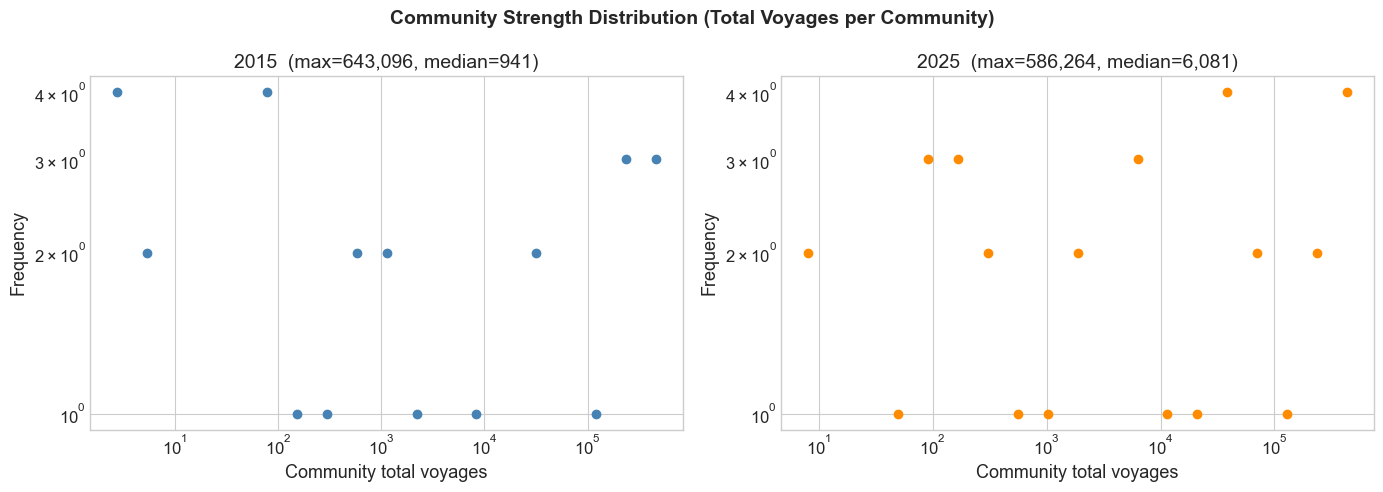

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Community Strength Distribution (Total Voyages per Community)',
             fontsize=14, fontweight='bold')

for ax, (year, cm, color) in zip(axes, [
    ('2015', cm_2015, 'steelblue'),
    ('2025', cm_2025, 'darkorange')
]):
    cs = cm['comm_strengths']
    cs_nz = cs[cs > 0]
    if len(cs_nz) > 1:
        bins = np.logspace(np.log10(cs_nz.min()), np.log10(cs_nz.max()), 20)
        h, edges = np.histogram(cs_nz, bins=bins)
        centres = np.sqrt(edges[:-1] * edges[1:])
        ax.loglog(centres[h > 0], h[h > 0], 'o', ms=6, color=color)
    ax.set_xlabel('Community total voyages')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{year}  (max={int(cs.max()):,}, median={int(np.median(cs)):,})')

plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_strength.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Top Ports per Community (Largest Communities)


In [7]:
def top_ports_per_community(Gu, comms, year, n_comms=8, ports_per_comm=8):
    """Print top ports by strength for the largest communities."""
    # Sort communities by size descending
    sorted_comms = sorted(enumerate(comms), key=lambda x: len(x[1]), reverse=True)

    print(f'\n=== Top ports per community — {year} (top {n_comms} communities by size) ===')

    for rank, (i, c) in enumerate(sorted_comms[:n_comms]):
        sub = Gu.subgraph(c)
        top = sorted(sub.degree(weight='weight'), key=lambda x: x[1], reverse=True)[:ports_per_comm]
        port_str = ', '.join(f'{p}({w:,})' for p, w in top)
        print(f'  Comm {rank+1:>2} (size={len(c):>4}): {port_str}')


top_ports_per_community(Gu_2015, comms_2015, '2015')
top_ports_per_community(Gu_2025, comms_2025, '2025')



=== Top ports per community — 2015 (top 8 communities by size) ===
  Comm  1 (size=1990): nld-rotterdammaasvlakte(22,291), bel-antwerp(17,928), deu-brunsbuttel(16,366), deu-strande(14,007), gbr-erith(11,267), deu-bremerhaven(11,130), deu-cuxhaven(10,474), deu-deu-482(9,755)
  Comm  2 (size= 970): tur-istanbul(28,151), rus-kavkaz(18,013), grc-piraeus(9,950), tur-yalovatown(8,458), egy-portsaid(8,356), rus-azov(7,410), esp-valencia(7,401), tur-ambarli(7,188)
  Comm  3 (size= 765): pan-manzanillo(9,738), pan-gatunlakeanchorage(6,909), pan-panamaanchoragepacific(5,861), usa-houston(5,018), col-cartagena(4,652), pan-panamacanalanchorage(4,651), usa-newyork(4,228), per-callao(4,081)
  Comm  4 (size= 715): mys-pengerang(16,726), mys-portklang(16,653), are-jebelali(12,804), sgp-singapore(12,276), idn-jakarta(10,201), lka-colombo(7,102), mys-tanjungpelepas(6,845), idn-surabaya(6,752)
  Comm  5 (size= 689): chn-shanghai(101,236), chn-ningbo(52,223), chn-caofeidian(24,488), chn-dalian(21,688), c

## 6. Summary Comparison Table


In [8]:
rows = [
    ('Metric',                          '2015',                              '2025',                              'Paper 2007'),
    ('Detection method',                 method_2015,                         method_2025,                         'Louvain'),
    ('Number of communities c',          str(len(comms_2015)),                str(len(comms_2025)),                '12 (container) / 7 (bulk) / 6 (oil)'),
    ('Modularity Q',                     f'{Q_2015:.4f}',                     f'{Q_2025:.4f}',                     '0.605 / 0.592 / 0.716'),
    ('Largest community (nodes)',        f'{cm_2015["sizes"].max()}',         f'{cm_2025["sizes"].max()}',         '—'),
    ('Smallest community (nodes)',       f'{cm_2015["sizes"].min()}',         f'{cm_2025["sizes"].min()}',         '—'),
    ('Mean community size',              f'{cm_2015["sizes"].mean():.1f}',    f'{cm_2025["sizes"].mean():.1f}',    '—'),
    ('Intra-community edge ratio',       f'{cm_2015["intra_ratio"]*100:.1f}%', f'{cm_2025["intra_ratio"]*100:.1f}%', '—'),
    ('Intra-community traffic ratio',    f'{cm_2015["intra_traffic_ratio"]*100:.1f}%',
                                         f'{cm_2025["intra_traffic_ratio"]*100:.1f}%', '—'),
    ('Mean internal density',            f'{np.mean(cm_2015["densities"]):.4f}',
                                         f'{np.mean(cm_2025["densities"]):.4f}', '—'),
]

df_sum = pd.DataFrame(rows[1:], columns=rows[0])

print()
print('=' * 90)
print('  GCSN COMMUNITY ANALYSIS — SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface')
print('=' * 90)
print(df_sum.to_string(index=False))
print('=' * 90)

df_sum.to_csv('../Figures/04_community_summary.csv', index=False)
print('\nSaved to ../Figures/04_community_summary.csv')



  GCSN COMMUNITY ANALYSIS — SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface
                       Metric    2015    2025                          Paper 2007
             Detection method Louvain Louvain                             Louvain
      Number of communities c      28      34 12 (container) / 7 (bulk) / 6 (oil)
                 Modularity Q  0.6987  0.7196               0.605 / 0.592 / 0.716
    Largest community (nodes)    1990    1735                                   —
   Smallest community (nodes)       2       2                                   —
          Mean community size   253.5   227.0                                   —
   Intra-community edge ratio   70.2%   67.6%                                   —
Intra-community traffic ratio   84.2%   83.4%                                   —
        Mean internal density  0.4647  0.3605                                   —

Saved to ../Figures/04_community_summary.csv
